In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
import warnings
from pathlib import Path
import sys
import os
from datetime import datetime

project_root = Path.cwd().parent.parent
project_root_str = str(project_root)

if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

os.chdir(project_root_str)

from src.utils.team_info import *
from src.utils.helper_functions import *
from src.pipeline.props_pipeline.ppm_pipeline import *
from src.pipeline.props_pipeline.min_pipeline import *
from src.pipeline.props_pipeline.rpm_pipeline import *
from src.features.feature_engineer.rpm_features import *

warnings.filterwarnings("ignore")

In [2]:
pd.set_option('display.max_columns', None)

s23 = pd.read_csv('data/raw/season_stats/S23.csv').sort_values(by='GAME_DATE')
s24 = pd.read_csv('data/raw/season_stats/S24.csv').sort_values(by='GAME_DATE')
s25 = pd.read_csv('data/raw/season_stats/S25.csv').sort_values(by='GAME_DATE')
s25['STARTING'] = s25['START_POSITION'].notna().astype(int)
s26 = pd.read_csv('data/raw/season_stats/S26.csv').sort_values(by='GAME_DATE')
s26['STARTING'] = s26['START_POSITION'].notna().astype(int)
s26.tail()

,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,START_POSITION,pos,age,STARTING
130,2025-26,1631172,Ousmane Dieng,Ousmane,1610612749,MIL,Milwaukee Bucks,22501126,2026-04-03T00:00:00,MIL vs. BOS,L,23.983333,4,15,0.267,1,4,0.250,0,0,0.0,0,3,3,1,1,0,0,1,2,0,9,-32,13.1,0,0,14.0,1,23:59,1,94.0,97.9,97.9,155.5,159.2,159.2,-61.5,-61.3,-61.3,0.091,1.0,5.9,0.000,0.158,0.060,5.9,5.9,0.300,0.300,0.296,0.297,99.19,96.07,80.06,96.07,-0.009,47,4.0,15.0,35,83,0.422,21,47,0.447,10,13,0.769,8,22,30,24,13.0,5,4,4,21,13,101,-32.0,107.8,109.8,138.0,141.5,-30.3,-31.7,0.686,1.85,19.0,0.200,0.600,0.378,0.141,0.548,0.569,95.0,93.0,77.50,92,0.322,1610612738,BOS,Boston Celtics,50,89,0.562,17,37,0.459,16,19,0.842,10,38,48,33,9.0,7,4,4,13,21,133,32.0,138.0,141.5,107.8,109.8,30.3,31.7,0.660,3.67,23.1,0.400,0.800,0.622,0.096,0.657,0.683,95.0,93.0,77.50,94,0.678,G,C,22.0,1
129,2025-26,1629013,Landry Shamet,Landry,1610612752,NYK,New York Knicks,22501123,2026-04-03T00:00:00,NYK vs. CHI,W,12.683333,3,7,0.429,2,4,0.500,0,0,0.0,1,0,1,1,0,1,0,0,0,0,8,12,13.7,0,0,14.0,1,12:41,1,143.6,137.0,137.0,95.9,92.6,92.6,47.8,44.4,44.4,0.083,0.0,12.5,0.083,0.000,0.037,0.0,0.0,0.571,0.571,0.233,0.243,98.09,102.18,85.15,102.18,0.105,27,3.0,7.0,48,91,0.527,15,39,0.385,25,28,0.893,13,41,54,30,9.0,11,3,2,21,23,136,40.0,136.9,136.0,96.5,96.0,40.4,40.0,0.625,3.33,20.7,0.333,0.788,0.577,0.090,0.610,0.658,99.4,100.0,83.33,100,0.713,1610612741,CHI,Chicago Bulls,35,81,0.432,11,35,0.314,15,26,0.577,9,27,36,24,16.0,4,2,3,23,21,96,-40.0,96.5,96.0,136.9,136.0,-40.4,-40.0,0.686,1.50,17.8,0.212,0.667,0.423,0.160,0.500,0.519,99.4,100.0,83.33,100,0.287,NaN,SG,28.0,0
128,2025-26,1630182,Josh Green,Josh,1610612766,CHA,Charlotte Hornets,22501120,2026-04-03T00:00:00,CHA vs. IND,W,24.400000,2,5,0.400,2,4,0.500,0,0,0.0,1,1,2,2,0,1,0,0,2,0,6,8,14.4,0,0,14.0,1,24:24,1,124.2,125.5,125.5,109.4,107.7,107.7,14.8,17.8,17.8,0.100,0.0,28.6,0.036,0.036,0.036,0.0,0.0,0.600,0.600,0.088,0.088,101.04,101.31,84.43,101.31,0.044,51,2.0,5.0,46,96,0.479,24,49,0.490,13,15,0.867,12,36,48,31,10.0,8,7,1,18,18,129,21.0,128.2,130.3,109.8,109.1,18.5,21.2,0.674,3.10,21.5,0.275,0.722,0.505,0.101,0.604,0.629,99.5,99.0,82.50,99,0.574,1610612754,IND,Indiana Pacers,43,93,0.462,15,36,0.417,7,10,0.700,11,34,45,29,12.0,5,1,7,18,18,108,-21.0,109.8,109.1,128.2,130.3,-18.5,-21.2,0.674,2.42,20.6,0.278,0.725,0.495,0.121,0.543,0.554,99.5,99.0,82.50,99,0.426,NaN,SG,25.0,0
139,2025-26,203937,Kyle Anderson,Kyle,1610612750,MIN,Minnesota T

In [3]:
def apply_bayesian_rpm(df, confidence_k=20, min_minutes=1.0):
    df = df.copy()
    df["_rpm"] = np.where(df["MIN"] >= min_minutes, df["REB"] / df["MIN"], np.nan)

    priors = df.groupby(["pos", "STARTING"], dropna=False)["_rpm"].mean().to_dict()

    player_stats = df.groupby("PLAYER_ID", as_index=False).agg(
        player_mean_rpm=("_rpm", "mean"),
        games_played=("_rpm", "count"),
    )

    df = df.merge(player_stats, on="PLAYER_ID", how="left")

    def _prior_for_row(row):
        key = (row["pos"], row["STARTING"])
        v = priors.get(key)
        if v is None or (isinstance(v, float) and np.isnan(v)):
            return float(df["_rpm"].mean())
        return float(v)

    df["prior_rpm"] = df.apply(_prior_for_row, axis=1)

    df["bayesian_rpm_proj"] = (
        (df["games_played"] * df["player_mean_rpm"]) + (confidence_k * df["prior_rpm"])
    ) / (df["games_played"] + confidence_k)

    df["bayesian_rpm_proj"] = df["bayesian_rpm_proj"].round(4)
    df = df.drop(columns=["_rpm"], errors="ignore")

    return df["bayesian_rpm_proj"]

In [4]:
res = []
for df in [s23, s24, s25, s26]:
    df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"])
    df = df.sort_values(["PLAYER_ID", "GAME_DATE"]).reset_index(drop=True)

    # Derived features
    df['MIN'] = df['MIN'].round(2)
    df["REB_PER_MIN"] = df["REB"] / df["MIN"].replace(0, np.nan)
    df["OREB_PER_MIN"] = df["OREB"] / df["MIN"].replace(0, np.nan)
    df["DREB_PER_MIN"] = df["DREB"] / df["MIN"].replace(0, np.nan)
    df['BAYES_RPM_PROJ'] = apply_bayesian_rpm(df)
    df = rpm_features(df)
    df['TEAM_REB_RANK_L5'] = (df.groupby(['TEAM_ID','GAME_DATE'])['REB_roll5'].rank(ascending=False, method='dense'))
    df['TEAM_REB_PER_MIN_RANK_L5'] = (df.groupby(['TEAM_ID','GAME_DATE'])['REB_PER_MIN_roll5'].rank(ascending=False, method='dense'))
    df['TEAM_REB_PER_MIN_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['REB_PER_MIN_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_MIN_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['MIN_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_MIN_RANK_L5'] = (df.groupby(['TEAM_ID','GAME_DATE'])['MIN_roll5'].rank(ascending=False, method='dense'))
    df['MEDIAN_REB_PER_MIN_L10'] = (df.groupby('PLAYER_ID')['REB_PER_MIN'].transform(lambda x: x.shift(1).rolling(10).median().round(2)))
    df['REB_PER_MIN_ewm5'] = (df.groupby('PLAYER_ID')['REB_PER_MIN'].transform(lambda x: x.shift(1).ewm(span=5, adjust=False).mean()))
    df['REB_PER_MIN_ewm10'] = (df.groupby('PLAYER_ID')['REB_PER_MIN'].transform(lambda x: x.shift(1).ewm(span=10, adjust=False).mean()))
    df['REB_ewm10'] = (df.groupby('PLAYER_ID')['REB'].transform(lambda x: x.shift(1).ewm(span=10, adjust=False).mean()))
    df['MIN_ewm10'] = (df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).ewm(span=10, adjust=False).mean()))
    df['MIN_ewm5'] = (df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).ewm(span=5, adjust=False).mean()))
    df["GP"] = df.groupby("PLAYER_ID").cumcount()
    df['POSITION_ENC'] = LabelEncoder().fit_transform(df['pos'])
    df["BLOWOUT_RISK"] = df.groupby("PLAYER_ID")["TEAM_PLUS_MINUS"].transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).std())
    player_avgs = df[df['MIN'] > 0].groupby('PLAYER_ID')['MIN'].apply(
    lambda x: (x >= 12).mean())
    eligible = player_avgs[player_avgs >= 0.60].index
    df = df[df['PLAYER_ID'].isin(eligible)]
    res.append(df)

df = pd.concat(res, ignore_index=True)
df.drop(columns=['Unnamed: 0'], inplace=True)
print(df.shape)
df.to_csv('data/processed/training/S26_TRAINING_RPM.csv', index=False)
df.tail()

(83106, 252)


,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,pos,age,STARTING,REB_PER_MIN,OREB_PER_MIN,DREB_PER_MIN,BAYES_RPM_PROJ,MIN_roll3,PLUS_MINUS_roll3,REB_roll3,REB_PCT_roll3,OREB_PCT_roll3,DREB_PCT_roll3,REB_PER_MIN_roll3,OREB_PER_MIN_roll3,DREB_PER_MIN_roll3,MIN_roll5,PLUS_MINUS_roll5,REB_roll5,REB_PCT_roll5,OREB_PCT_roll5,DREB_PCT_roll5,REB_PER_MIN_roll5,OREB_PER_MIN_roll5,DREB_PER_MIN_roll5,MIN_roll10,PLUS_MINUS_roll10,REB_roll10,REB_PCT_roll10,OREB_PCT_roll10,DREB_PCT_roll10,REB_PER_MIN_roll10,OREB_PER_MIN_roll10,DREB_PER_MIN_roll10,MIN_lag1,PLUS_MINUS_lag1,REB_lag1,REB_PCT_lag1,OREB_PCT_lag1,DREB_PCT_lag1,STARTING_lag1,MIN_lag2,PLUS_MINUS_lag2,REB_lag2,REB_PCT_lag2,OREB_PCT_lag2,DREB_PCT_lag2,STARTING_lag2,STARTER_ROLL10_PCT,MIN_season_avg,REB_season_avg,REB_PCT_season_avg,OREB_PCT_season_avg,DREB_PCT_season_avg,TEAM_PACE_roll5,TEAM_REB_roll5,TEAM_FG_PCT_roll5,TEAM_FGA_roll5,TEAM_FG3A_roll5,MIN_share_proxy_roll5,REB_share_proxy_roll5,DAYS_REST,IS_B2B,IS_HOME,GAME_NUMBER,MIN_std10,REB_std10,OPP_DEF_RATING_roll5,OPP_DEF_RATING_roll10,OPP_PACE_roll5,OPP_PACE_roll10,OPP_POSS_roll5,OPP_POSS_roll10,OPP_FG_PCT_roll5,OPP_FG_PCT_roll10,OPP_FGA_roll5,OPP_FGA_roll10,OPP_FG3A_roll5,OPP_FG3A_roll10,EXPECTED_PACE,PACE_DIFFERENTIAL,PLAYER_IS_TEAM_STAR,STAR_SAT_OUT,TEAM_REB_RANK_L5,TEAM_REB_PER_MIN_RANK_L5,TEAM_REB_PER_MIN_RANK_L10,TEAM_MIN_RANK_L10,TEAM_MIN_RANK_L5,MEDIAN_REB_PER_MIN_L10,REB_PER_MIN_ewm5,REB_PER_MIN_ewm10,REB_ewm10,MIN_ewm10,MIN_ewm5,GP,POSITION_ENC,BLOWOUT_RISK,START_POSITION
83101,2025-26,1643158,Andersson Garcia,Andersson,1610612762,UTA,Utah Jazz,22500967,2026-03-13,UTA @ POR,L,28.55,2,6,0.333,0,3,0.000,2,2,1.000,2,1,3,2,3,2,0,0,4,4,6,-11,15.6,0,0,15.0,1,28:33,1,86.3,88.7,88.7,106.0,103.1,103.1,-19.7,-14.4,-14.4,0.111,0.67,16.7,0.057,0.032,0.045,25.0,25.3,0.333,0.436,0.137,0.138,105.92,105.92,88.27,105.92,0.009,62,2.0,6.0,42,92,0.457,13,30,0.433,17,22,0.773,10,26,36,28,18.0,16,3,12,17,19,114,-10.0,103.9,107.5,116.9,115.9,-13.0,-8.3,0.667,1.56,18.8,0.294,0.636,0.453,0.170,0.527,0.561,107.9,106.5,88.75,106,0.427,1610612757,POR,Portland Trail Blazers,46,89,0.517,17,46,0.370,15,16,0.938,14,35,49,34,24.0,16,12,3,19,17,124,10.0,116.9,115.9,103.9,107.5,13.0,8.3,0.739,1.42,21.8,0.364,0.706,0.547,0.224,0.612,0.646,107.9,106.5,88.75,107,0.573,SF,25.0,0,0.105079,0.070053,0.035026,0.1884,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.05,-31.0,9.0,0.180,0.172,0.190,0

In [5]:
RPM_FEATURES = [
    'BAYES_RPM_PROJ',
    'REB_PCT_roll5',
    'OREB_PCT_roll5',
    'DREB_PCT_roll5',
    'REB_PER_MIN_roll5',
    'OREB_PER_MIN_roll5',
    'DREB_PER_MIN_roll5',
    'MEDIAN_REB_PER_MIN_L10', #new
    'MIN_ewm10',
    'MIN_ewm5',
    'TEAM_REB_PER_MIN_RANK_L5',
    'TEAM_REB_RANK_L5',
    'TEAM_FG_PCT_roll5',
    'TEAM_PACE_roll5',
    'OPP_PACE_roll5',
    'OPP_DEF_RATING_roll5',
    'OPP_FG_PCT_roll5',
    'OPP_FG3A_roll5',
    'DAYS_REST',
    'IS_B2B',
    'STARTING',
    'POSITION_ENC',
    'GP',
]

In [6]:
ppm_df = df[RPM_FEATURES + ["REB_PER_MIN", "MIN", "GAME_DATE"]].dropna()

split_date = ppm_df["GAME_DATE"].quantile(0.75)
train_mask = ppm_df["GAME_DATE"] <= split_date
val_mask = ~train_mask

X_train_ppm = ppm_df.loc[train_mask, RPM_FEATURES]
y_train_ppm = ppm_df.loc[train_mask, "REB_PER_MIN"]
X_val_ppm   = ppm_df.loc[val_mask, RPM_FEATURES]
y_val_ppm   = ppm_df.loc[val_mask, "REB_PER_MIN"]

quantiles = [0.10, 0.50, 0.90]
quantile_models = {}
quantile_preds = {}

for q in quantiles:
    q_float = float(q)
    key = f"q_{q_float:.2f}"
    print(f"Training model for Quantile: {key}...")

    xgb_q = XGBRegressor(
        objective="reg:quantileerror",
        quantile_alpha=q_float,
        n_estimators=800,
        max_depth=8,
        min_child_weight=1,
        subsample=0.8,
        colsample_bytree=0.8,
        learning_rate=0.01,
        reg_lambda=0.1,
        reg_alpha=0.1,
        random_state=42,
        n_jobs=-1,
    )

    xgb_q.fit(
        X_train_ppm,
        y_train_ppm,
        eval_set=[(X_val_ppm, y_val_ppm)],
        verbose=False,
    )

    quantile_models[key] = xgb_q
    quantile_preds[key] = xgb_q.predict(X_val_ppm)

results_df = X_val_ppm.copy()
results_df["Actual"] = y_val_ppm.values
results_df["Lower_10"] = quantile_preds["q_0.10"]
results_df["Median_50"] = quantile_preds["q_0.50"]
results_df["Upper_90"] = quantile_preds["q_0.90"]
results_df["MIN"] = ppm_df.loc[val_mask, "MIN"].values

# Optional: high-minute slice for diagnostics (PPM vs actual PTS/min when MIN >= 35)
high_min_stars = results_df[results_df["MIN"] >= 35]

print("\n--- Val rows with Actual MIN >= 35 (PPM model, target = REB_PER_MIN) ---")
print(f"Average Actual REB/MIN: {high_min_stars['Actual'].mean():.3f}")
print(f"Avg Median Pred REB/MIN: {high_min_stars['Median_50'].mean():.3f}")

q50_mae = mean_absolute_error(y_val_ppm, quantile_preds["q_0.50"])
q50_rmse = np.sqrt(mean_squared_error(y_val_ppm, quantile_preds["q_0.50"]))
q50_r2 = r2_score(y_val_ppm, quantile_preds["q_0.50"])

print(f"\n[Overall Median Model] MAE: {q50_mae:.3f} PTS/min")
print(f"RMSE: {q50_rmse:.3f} PTS/min")
print(f"R-squared: {q50_r2:.2f}")

Training model for Quantile: q_0.10...
Training model for Quantile: q_0.50...
Training model for Quantile: q_0.90...

--- Val rows with Actual MIN >= 35 (PPM model, target = REB_PER_MIN) ---
Average Actual REB/MIN: 0.175
Avg Median Pred REB/MIN: 0.169

[Overall Median Model] MAE: 0.073 PTS/min
RMSE: 0.098 PTS/min
R-squared: 0.38


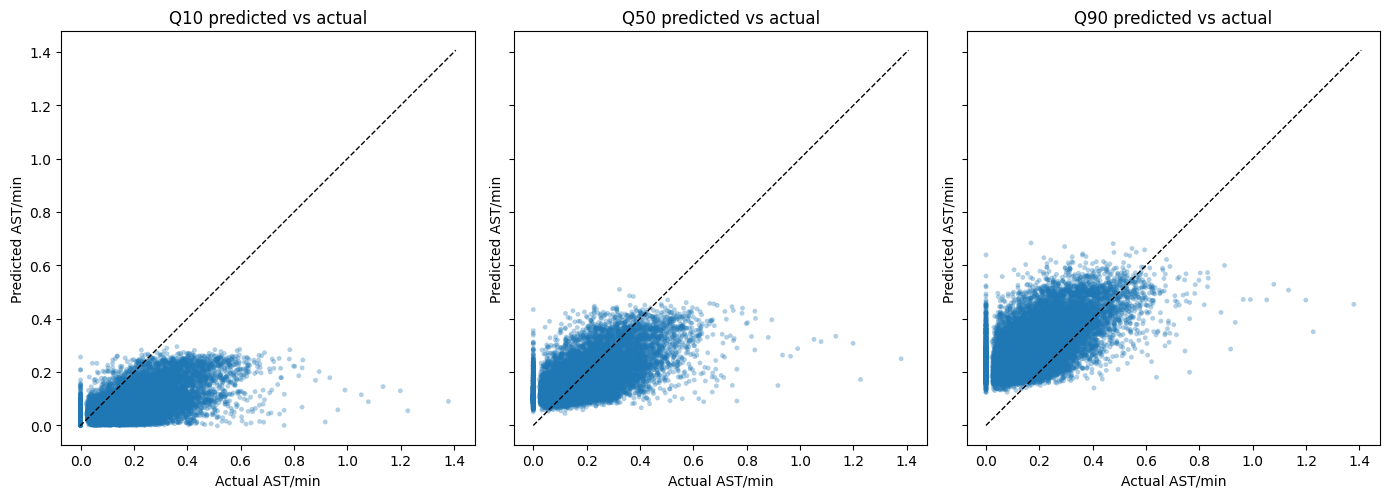

Q10 P(y ≤ pred): 0.12013575984551465
Q50 P(y ≤ pred): 0.4996781555386506
Q90 P(y ≤ pred): 0.8859500263327287
Coverage (10–90 interval): 76.58%


In [7]:
import matplotlib.pyplot as plt

y_true = y_val_ppm
preds = {
    "Q10": quantile_preds["q_0.10"],
    "Q50": quantile_preds["q_0.50"],
    "Q90": quantile_preds["q_0.90"],
}

fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharex=True, sharey=True)
for ax, (name, y_pred) in zip(axes, preds.items()):
    ax.scatter(y_true, y_pred, s=12, edgecolors="none", alpha=0.35)
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    lims = [lo, hi * 1.02 if hi > 0 else hi + 0.01]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_title(f"{name} predicted vs actual")
    ax.set_xlabel("Actual AST/min")
    ax.set_ylabel("Predicted AST/min")
    ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

for name, y_pred in preds.items():
    print(name, "P(y ≤ pred):", (y_true <= y_pred).mean())

pred_low = quantile_preds["q_0.10"]
pred_mid = quantile_preds["q_0.50"]
pred_high = quantile_preds["q_0.90"]

coverage = ((y_true >= pred_low) & (y_true <= pred_high)).mean()
print(f"Coverage (10–90 interval): {coverage:.2%}")  # target ~80%

In [8]:
# Use quantile regression to get a range instead of a single number
from sklearn.ensemble import GradientBoostingRegressor

lower = GradientBoostingRegressor(loss='quantile', alpha=0.1)
upper = GradientBoostingRegressor(loss='quantile', alpha=0.9)
mid   = GradientBoostingRegressor(loss='quantile', alpha=0.5)

lower.fit(X_train_ppm, y_train_ppm)
upper.fit(X_train_ppm, y_train_ppm)
mid.fit(X_train_ppm, y_train_ppm)

pred_low  = lower.predict(X_val_ppm)
pred_high = upper.predict(X_val_ppm)
pred_mid  = mid.predict(X_val_ppm)

# Coverage — what % of actuals fall within the interval?
coverage = ((y_val_ppm >= pred_low) & (y_val_ppm <= pred_high)).mean()
print(f"Coverage: {coverage:.2%}")  # want this close to 80%

Coverage: 78.94%


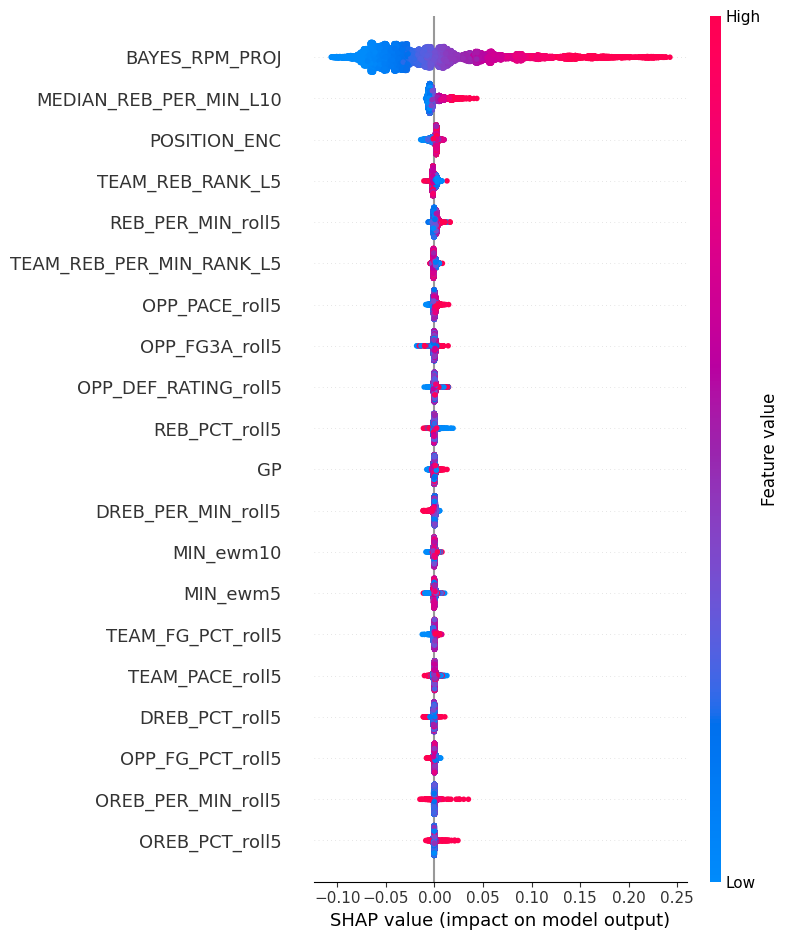

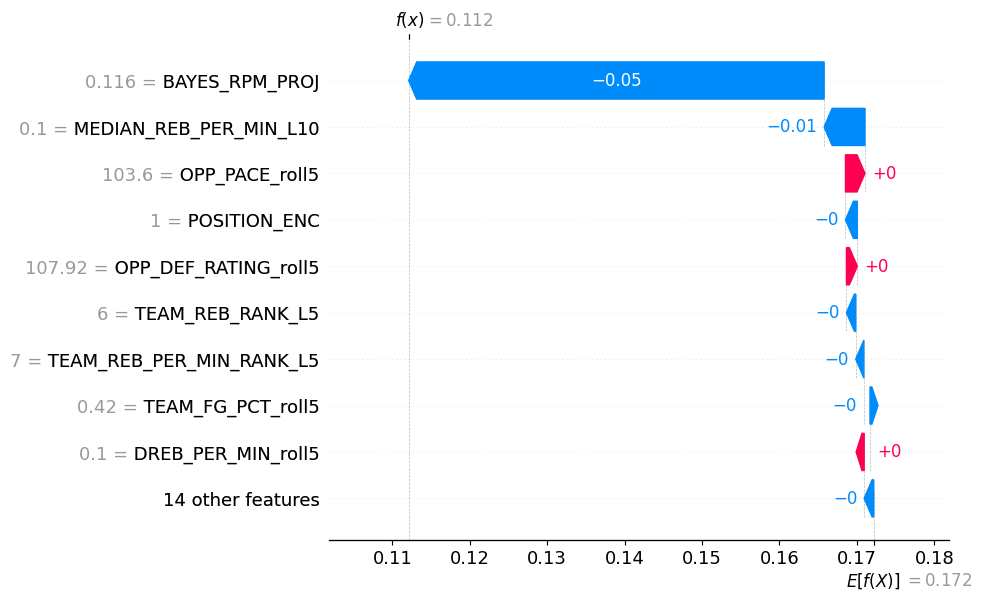

In [9]:
import shap

model = quantile_models["q_0.50"]   
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_val_ppm)
shap.summary_plot(shap_values, X_val_ppm, feature_names=RPM_FEATURES)
shap.plots.waterfall(shap_values[1154])

In [10]:
import joblib
from pathlib import Path

out_dir = Path("rpm_quantile")  # or wherever you prefer
out_dir.mkdir(parents=True, exist_ok=True)

bundle = {
    "quantile_models": quantile_models,
    "feature_names": RPM_FEATURES,  # or list(X_train_min.columns)
}
joblib.dump(bundle, out_dir / "rpm_quantile_xgb.joblib")

['rpm_quantile/rpm_quantile_xgb.joblib']

In [11]:
from src.utils.scrap_starters import NBADailyLineups

scraper = NBADailyLineups("https://www.rotowire.com/basketball/nba-lineups.php")
scraper.getDict()  # Scrape the lineups
print("\nQuestionable Players:")
print(scraper.getQuestionablePlayers())
print("\nOut Players:")
print(scraper.getOutPlayers())
outPlayers = scraper.getOutPlayers()
scraper.updateTeamInfo()  # Update teamInfo.py


Questionable Players:
{'DEN': ['Bruce Brown'], 'PHI': ['Cameron Payne']}

Out Players:
{'SAS': ['Emanuel Miller'], 'DEN': ['Spencer Jones', 'Zeke Nnaji', 'Peyton Watson'], 'WAS': ['Tristan Vukcevic', 'Anthony Davis', 'Trae Young', 'Alex Sarr', "D'Angelo Russell"], 'MIA': ['Norman Powell', 'Tyler Herro', 'Terry Rozier'], 'DET': ['Cade Cunningham', 'Isaiah Stewart'], 'PHI': ['Johni Broome', 'Joel Embiid']}
Successfully updated /Users/alexgonzalez/Documents/NBA-Prop-Predictor/src/utils/team_info.py
Updated 6 teams with confirmed lineups
Updated 2 teams with questionable players


In [5]:
date = pd.Timestamp.now().normalize()  # midnight today, local tz
current_date = date.strftime("%Y-%m-%d")

# target_date = pd.Timestamp("2026-03-26")
# hist = df[df["GAME_DATE"] < target_date].copy()

lines_dfs = pd.read_csv('data/raw/player_lines/NBA_DFS_20260403_163051.csv')
lines_us = pd.read_csv('data/raw/player_lines/NBA_US_20260403_163203.csv')
lines_dfs = lines_dfs[(lines_dfs['BOOKMAKER'] == 'Underdog') & (lines_dfs['CATEGORY'] == 'player_rebounds')]
names = lines_dfs['NAME'].unique()
names

array(['Onyeka Okongwu', 'Mouhamed Gueye', 'Drake Powell', 'Noah Clowney',
       'Jalen Brunson', 'Josh Giddey', 'Isaac Okoro', 'Jayson Tatum',
       'Payton Pritchard', 'Neemias Queta', 'Jericho Sims', 'A.J. Green',
       'Alperen Sengun', 'Jabari Smith Jr', 'Amen Thompson',
       'Brice Sensabaugh', 'Collin Murray-Boyles', 'Javon Small',
       'Wendell Carter Jr', 'Zion Williamson', 'Saddiq Bey',
       'Derik Queen', 'Jeremiah Fears', 'Nique Clifford', 'Nikola Jokic',
       'Devin Vassell', 'Aaron Gordon', 'Cameron Johnson',
       'Julian Champagnie'], dtype=object)

In [6]:
import joblib

min_bundle = joblib.load("src/models/saved_models/min_quantile_xgb.joblib")
min_quantile_models = min_bundle["quantile_models"]
min_feature_names = min_bundle["feature_names"]

rpm_bundle = joblib.load("src/models/saved_models/rpm_quantile_xgb.joblib")
rpm_quantile_models = rpm_bundle["quantile_models"]
rpm_feature_names = rpm_bundle["feature_names"]

## MIN + RPM (ANALYSIS)

In [7]:
records = []

for name in names:
    try:
        if name in nameDict:
            name = nameDict[name]

        min_feats = min_pipeline(df, name)
        if min_feats is None:
            raise ValueError("min_pipeline returned None (need >= 10 games)")

        rpm_feats = rpm_pipeline(df, name, current_date)
        # ppm_pipeline returns a list aligned with PPM_FEATURES / training columns

        min_arr = np.asarray(min_feats, dtype=float).reshape(1, -1)
        rpm_arr = np.asarray(rpm_feats, dtype=float).reshape(1, -1)

        m10 = float(min_quantile_models["q_0.10"].predict(min_arr)[0])
        m50 = float(min_quantile_models["q_0.50"].predict(min_arr)[0])
        m90 = float(min_quantile_models["q_0.90"].predict(min_arr)[0])

        p10 = float(rpm_quantile_models["q_0.10"].predict(rpm_arr)[0])
        p50 = float(rpm_quantile_models["q_0.50"].predict(rpm_arr)[0])
        p90 = float(rpm_quantile_models["q_0.90"].predict(rpm_arr)[0])

        # implied PTS = minutes × PTS per minute (same quantile index on both sides)
        pts10 = m10 * p10
        pts50 = m50 * p50
        pts90 = m90 * p90

        records.append({
            "PLAYER_NAME": name,
            "PRED_MIN_Q10": m10,
            "PRED_MIN_Q50": m50,
            "PRED_MIN_Q90": m90,
            "PRED_RPM_Q10": p10,
            "PRED_RPM_Q50": p50,
            "PRED_RPM_Q90": p90,
            "PRED_REB_Q10": round(pts10, 2),
            "PRED_REB_Q50": round(pts50, 2),
            "PRED_REB_Q90": round(pts90, 2),
            "PRED_REB_RANGE_10_90": round(pts90 - pts10, 2),
        })

    except Exception as e:
        records.append({
            "PLAYER_NAME": name,
            "PRED_MIN_Q10": np.nan,
            "PRED_MIN_Q50": np.nan,
            "PRED_MIN_Q90": np.nan,
            "PRED_RPM_Q10": np.nan,
            "PRED_RPM_Q50": np.nan,
            "PRED_RPM_Q90": np.nan,
            "PRED_REB_Q10": np.nan,
            "PRED_REB_Q50": np.nan,
            "PRED_REB_Q90": np.nan,
            "PRED_REB_RANGE_10_90": np.nan,
        })
        print(f"[SKIP] {name}: {e}")

preds_df = pd.DataFrame(records)
preds_df.head()

[SKIP] A.J. Green: min_pipeline returned None (need >= 10 games)
[SKIP] Wendell Carter Jr: min_pipeline returned None (need >= 10 games)


,PLAYER_NAME,PRED_MIN_Q10,PRED_MIN_Q50,PRED_MIN_Q90,PRED_RPM_Q10,PRED_RPM_Q50,PRED_RPM_Q90,PRED_REB_Q10,PRED_REB_Q50,PRED_REB_Q90,PRED_REB_RANGE_10_90
0,Onyeka Okongwu,21.597481,29.285728,35.174381,0.142056,0.277640,0.429435,3.07,8.13,15.11,12.04
1,Mouhamed Gueye,10.524119,20.516014,28.790682,0.174265,0.238183,0.449811,1.83,4.89,12.95,11.12
2,Drake Powell,18.227821,27.317287,33.370060,0.020171,0.073065,0.151459,0.37,2.00,5.05,4.69
3,Noah Clowney,13.896731,20.445385,25.471516,0.056366,0.148634,0.319443,0.78,3.04,8.14,7.35
4,Jalen Brunson,30.662828,36.435535,39.150387,0.020125,0.097028,0.184808,0.62,3.54,7.24,6.62


In [8]:
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# 1. THE CORE SIMULATION ENGINE (POISSON-BASED)
# ---------------------------------------------------------

def triangular_clip(row, q10, q50, q90, lo_scale=0.70, hi_scale=1.30, low=0.0, high=np.inf, n_sims=10_000):
    """
    Generates a triangular distribution based on XGBoost quantiles.
    Widening the scales (lo_scale, hi_scale) introduces 'NBA Chaos' (fouls, blowouts).
    """
    mode = float(row[q50])
    # Ensure left < mode < right
    left = min(float(row[q10]) * lo_scale, mode - 0.001)
    right = max(float(row[q90]) * hi_scale, mode + 0.001)
    
    if not (np.isfinite(left) and np.isfinite(mode) and np.isfinite(right)):
        return np.full(n_sims, mode if np.isfinite(mode) else 0.0)
    
    # Generate continuous samples
    samples = np.random.triangular(left, mode, right, size=n_sims)
    return np.clip(samples, low, high)

def run_stat_simulation(row, stat_prefix="RPM", n_sims=10_000):
    """
    Paired simulation: Minutes * Rate.
    Converts expected continuous value into discrete integers using Poisson.
    """
    # Simulate Minutes
    sim_min = triangular_clip(
        row,
        "PRED_MIN_Q10", "PRED_MIN_Q50", "PRED_MIN_Q90",
        lo_scale=0.75, hi_scale=1.25, low=0, high=48, n_sims=n_sims,
    )
    
    # Simulate Rate (APM or RPM)
    sim_rate = triangular_clip(
        row,
        f"PRED_{stat_prefix}_Q10", f"PRED_{stat_prefix}_Q50", f"PRED_{stat_prefix}_Q90",
        lo_scale=0.70, hi_scale=1.30, low=0, high=np.inf, n_sims=n_sims,
    )
    
    # Calculate Lambda (Expected value for each sim)
    expected_val = sim_min * sim_rate
    
    # Poisson Sampling: The 'Counting' Step
    # This turns 7.4 expected rebounds into a distribution of 6, 7, 8, 9...
    sim_counts = np.random.poisson(lam=expected_val)
    
    return sim_counts

# ---------------------------------------------------------
# 2. LINE LOOKUP & MAPPING
# ---------------------------------------------------------

def _line_lookup_from_lines_df(ldf: pd.DataFrame, name_dict: dict) -> dict:
    """
    Maps sportsbook names to canonical dataset names.
    Handles 'Jokic' vs 'Jokić' logic.
    """
    d = {}
    for _, r in ldf.iterrows():
        book_name = str(r["NAME"]).strip()
        line = r["LINE"]
        d[book_name] = line
        
        # Add the canonical version if it exists in your nameDict
        canon = name_dict.get(book_name)
        if canon:
            d[canon] = line
            
    # Reverse check: ensure variants point to the line if canon was found
    for variant, canon in name_dict.items():
        if canon in d and variant not in d:
            d[variant] = d[canon]
    return d

# ---------------------------------------------------------
# 3. EXECUTION LOOP
# ---------------------------------------------------------

# Build the lookup
line_by_name = _line_lookup_from_lines_df(lines_dfs, nameDict)

results = []
for _, row in preds_df.iterrows():
    name = row["PLAYER_NAME"]
    line = line_by_name.get(name)
    
    # Validation
    if line is None or np.isnan(row.get("PRED_MIN_Q50", np.nan)):
        results.append({
            "PLAYER_NAME": name, "LINE": np.nan, 
            "P_OVER": np.nan, "P_UNDER": np.nan, "P_PUSH": np.nan
        })
        continue

    # Run the Poisson Simulation (Change prefix to 'APM' for Assists)
    stat_sims = run_stat_simulation(row, stat_prefix="RPM", n_sims=10_000)
    line = float(line)
    
    # Calculate Integer-Aware Probabilities
    p_over = float(np.mean(stat_sims > line))
    p_under = float(np.mean(stat_sims < line))
    p_push = float(np.mean(stat_sims == line))

    # Calculate Edge and EV
    # Assuming -119 odds (~1.84x payout) for Underdog standard
    # EV = (P_win * Profit) - (P_loss * Stake)
    # Simplified here for relative ranking:
    edge = row["PRED_REB_Q50"] - line 
    
    results.append({
        "PLAYER_NAME": name,
        "LINE": line,
        "PRED_MIN_Q50": round(row["PRED_MIN_Q50"], 2), 
        "PRED_STAT_Q50": round(row["PRED_REB_Q50"], 2),
        "P_OVER": round(p_over, 3), 
        "P_UNDER": round(p_under, 3),
        "P_PUSH": round(p_push, 3),
        "EDGE": round(edge, 2),
        "EV": round((p_over * 10) - (p_under * 10), 2) # Weighted directional EV
    })

# Create final DataFrame
line_probs_df = pd.DataFrame(results)

# Sort by absolute edge to find the biggest discrepancies
line_probs_df['ABS_EDGE'] = line_probs_df['EDGE'].abs()
line_probs_df = line_probs_df.sort_values(by="ABS_EDGE", ascending=False)

# Display top plays
print(line_probs_df[['PLAYER_NAME', 'LINE', 'PRED_STAT_Q50', 'P_OVER', 'P_UNDER', 'P_PUSH', 'EDGE']].head(15))

         PLAYER_NAME  LINE  PRED_STAT_Q50  P_OVER  P_UNDER  P_PUSH  EDGE
10      Jericho Sims   7.5           5.24   0.329    0.671     0.0 -2.26
12    Alperen Sengun   8.5          10.05   0.660    0.340     0.0  1.55
1     Mouhamed Gueye   3.5           4.89   0.799    0.201     0.0  1.39
26      Aaron Gordon   4.5           5.73   0.717    0.283     0.0  1.23
5        Josh Giddey   7.5           8.61   0.633    0.367     0.0  1.11
21       Derik Queen   6.5           7.53   0.680    0.320     0.0  1.03
14     Amen Thompson   7.5           8.46   0.619    0.381     0.0  0.96
25     Devin Vassell   3.5           4.31   0.689    0.311     0.0  0.81
7       Jayson Tatum   8.5           9.25   0.673    0.327     0.0  0.75
6        Isaac Okoro   2.5           3.18   0.695    0.305     0.0  0.68
0     Onyeka Okongwu   7.5           8.13   0.613    0.387     0.0  0.63
24      Nikola Jokić  13.5          14.02   0.551    0.449     0.0  0.52
2       Drake Powell   2.5           2.00   0.447  